<a href="https://colab.research.google.com/github/tyagisoumya16/Bitcoin-Sentiment/blob/main/Bitcoin_Sentiment_vs_Trader_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART A



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
fear_greed = pd.read_csv('fear_greed_index.csv')
historical = pd.read_csv('historical_data.csv')

In [28]:
print("Fear dataset shape:", fear.shape)
print("Trades dataset shape:", trades.shape)

Fear dataset shape: (2644, 4)
Trades dataset shape: (211224, 16)


In [29]:
fear.columns
trades.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')

In [30]:
fear.isnull().sum()
trades.isnull().sum()

,0
account,0
coin,0
execution_price,0
size_tokens,0
size_usd,0
side,0
timestamp_ist,0
start_position,0
direction,0
closed_pnl,0


In [31]:
fear.duplicated().sum()
trades.duplicated().sum()

np.int64(0)

In [32]:
fear = fear.drop_duplicates()
trades = trades.drop_duplicates()

In [33]:
fear['date'] = pd.to_datetime(fear['date'])
fear['date'] = fear['date'].dt.date

In [35]:
print(trades.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


In [36]:
trades.columns = trades.columns.str.strip()
print(trades.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


In [42]:
trades['timestamp_ist'] = pd.to_datetime(
    trades['timestamp_ist'],
    dayfirst=True
)

In [43]:
trades['date'] = trades['timestamp_ist'].dt.date

In [44]:
merged = trades.merge(fear[['date', 'classification']], on='date', how='left')

In [45]:
merged.head()
merged['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


In [51]:
print(merged.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'date', 'classification'],
      dtype='object')


In [52]:
daily_pnl = merged.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()

In [53]:
merged['win'] = (merged['closed_pnl'] > 0).astype(int)

win_rate = merged.groupby('account')['win'].mean().reset_index()

In [54]:
long_short = merged.groupby(['date','side']).size().unstack()

In [55]:
avg_trade_size = merged.groupby('account')['size_usd'].mean().reset_index()

PART B




1. Does performance differ between Fear vs Greed days?
2. Do traders change behavior based on sentiment?

In [56]:
pnl_sentiment = merged.groupby('classification')['closed_pnl'].mean()
print(pnl_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closed_pnl, dtype: float64


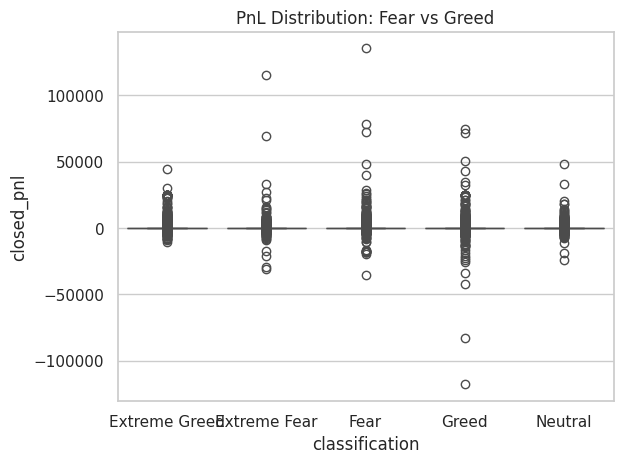

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='closed_pnl', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

In [58]:
merged['win'] = (merged['closed_pnl'] > 0).astype(int)

win_rate_sentiment = merged.groupby('classification')['win'].mean()
print(win_rate_sentiment)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


In [59]:
loss_analysis = merged[merged['closed_pnl'] < 0].groupby('classification')['closed_pnl'].mean()
print(loss_analysis)

classification
Extreme Fear    -257.099629
Extreme Greed   -119.920289
Fear            -156.662401
Greed           -181.967329
Neutral         -121.727849
Name: closed_pnl, dtype: float64


In [60]:
trade_freq = merged.groupby('classification').size()
print(trade_freq)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


In [62]:
size_analysis = merged.groupby('classification')['size_usd'].mean()
print(size_analysis)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64


In [63]:
long_short = merged.groupby(['classification','side']).size().unstack()

long_short['long_ratio'] = long_short['BUY'] / (long_short['BUY'] + long_short['SELL'])

print(long_short)

side              BUY   SELL  long_ratio
classification                          
Extreme Fear    10935  10465    0.510981
Extreme Greed   17940  22052    0.448590
Fear            30270  31567    0.489513
Greed           24576  25727    0.488559
Neutral         18969  18717    0.503343


3. Identify 2–3 segments (examples):
high leverage vs low leverage traders
frequent vs infrequent traders
consistent winners vs inconsistent traders
4. Provide at least 3 insights backed by charts/tables.


In [64]:
median_size = merged['size_usd'].median()

merged['size_segment'] = merged['size_usd'].apply(
    lambda x: 'High Size' if x > median_size else 'Low Size'
)

In [65]:
merged.groupby(['size_segment','classification'])['closed_pnl'].mean()

size_segment  classification
High Size     Extreme Fear       61.196379
              Extreme Greed     140.570044
              Fear               97.025581
              Greed              84.301244
              Neutral            69.581271
Low Size      Extreme Fear        1.157202
              Extreme Greed       9.628661
              Fear                3.580906
              Greed               3.609685
              Neutral             2.188668
Name: closed_pnl, dtype: float64

In [66]:
trade_count = merged.groupby('account').size()
threshold = trade_count.median()

merged['freq_segment'] = merged['account'].apply(
    lambda x: 'Frequent' if trade_count[x] > threshold else 'Infrequent'
)

In [67]:
merged.groupby(['freq_segment','classification'])['closed_pnl'].mean()

freq_segment  classification
Frequent      Extreme Fear       34.163353
              Extreme Greed      62.870911
              Fear               51.323784
              Greed              25.004641
              Neutral            34.579701
Infrequent    Extreme Fear       35.941979
              Extreme Greed     103.264685
              Fear               80.835791
              Greed             210.210287
              Neutral            31.845656
Name: closed_pnl, dtype: float64

In [68]:
total_pnl = merged.groupby('account')['closed_pnl'].sum()

merged['winner_segment'] = merged['account'].apply(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)

In [69]:
merged.groupby(['winner_segment','classification'])['closed_pnl'].mean()

winner_segment  classification
Loser           Extreme Fear      -22.598398
                Extreme Greed      51.702381
                Fear               46.768567
                Greed            -202.027754
                Neutral            17.327765
Winner          Extreme Fear       37.989084
                Extreme Greed      68.000450
                Fear               54.792435
                Greed              54.444738
                Neutral            35.049780
Name: closed_pnl, dtype: float64

PART C

Idea 1: If you observe:
1.Losses are larger in Fear
2.Volatility higher in Fear

Then During Fear days, reduce position size by 25–40% and avoid increasing trade frequency.

Idea 2: If you observe:
Higher win rate in Greed
Long bias stronger in Greed

Then During Greed days, increase long exposure and allow slightly larger position sizing for consistent winners.

Idea 3: If frequent traders perform worse in Fear:
During Fear sentiment, restrict overtrading behavior and enforce max trades per day rule.

Optional Bonus

In [70]:
daily_pnl = merged.groupby(['account','date','classification'])['closed_pnl'].sum().reset_index()

daily_pnl['profit_flag'] = (daily_pnl['closed_pnl'] > 0).astype(int)

In [71]:
daily_pnl['sentiment_flag'] = daily_pnl['classification'].map({'Fear':0,'Greed':1})

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = daily_pnl[['sentiment_flag']]
y = daily_pnl['profit_flag']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train,y_train)

print("Accuracy:", model.score(X_test,y_test))

Accuracy: 0.594017094017094
